Imię | Nazwisko | nr. idenksu
-|-|-
Natan | Jabłoński | 155621

In [2]:
import sys
from matplotlib import pyplot as plt

sys.path.append("../")

from src.dataset import EyeDataset

dataset = EyeDataset("../data/healthy/", "../data/healthy_manualsegm")

img, mask = dataset[0]




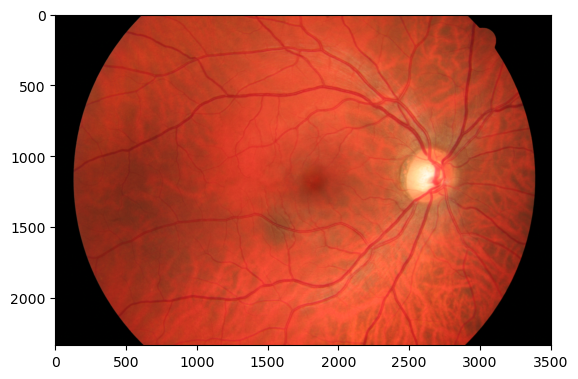

In [3]:
plt.imshow(img.permute(1,2,0))
plt.show()

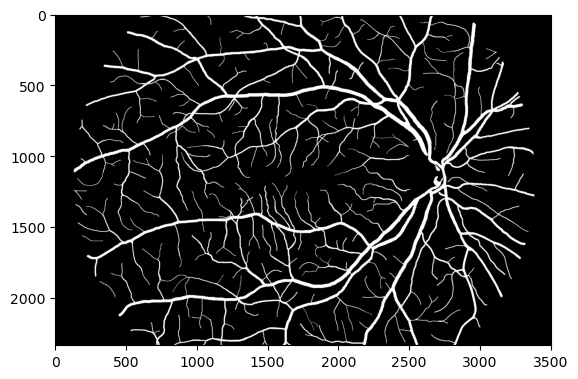

In [4]:
plt.imshow(mask.squeeze(), cmap="gray")
plt.show() #AUC ROC

In [6]:
from torch.utils.data import DataLoader
import torch

train_loader = DataLoader(dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(dataset, batch_size=1, shuffle=False)
test_loader  = DataLoader(dataset, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from skimage import color, filters

X_list = []
y_list = []

for img_tensor, mask_tensor in train_loader:
    img = img_tensor.squeeze(0).numpy()
    mask = mask_tensor.squeeze(0).numpy()

    H, W = mask[0].shape

    R = img[0].ravel()
    G = img[1].ravel()
    B = img[2].ravel()

    gray = 0.2989*img[0] + 0.5870*img[1] + 0.1140*img[2]
    edges = filters.sobel(gray).ravel()

    features = np.stack([R, G, B, edges], axis=1)
    labels = mask.ravel()

    X_list.append(features)
    y_list.append(labels)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print("Feature shape:", X.shape, "Labels shape:", y.shape)

Feature shape: (122780160, 4) Labels shape: (122780160,)


In [ ]:
clf = RandomForestClassifier(n_estimators=10, max_depth=3, n_jobs=-1)
clf.fit(X, y)

In [ ]:
img_tensor, mask_tensor = train_dataset[0]
img = img_tensor.numpy()  # (3, H, W)
H, W = img.shape[1], img.shape[2]

R = img[0].ravel()
G = img[1].ravel()
B = img[2].ravel()
gray = 0.2989*img[0] + 0.5870*img[1] + 0.1140*img[2]
edges = filters.sobel(gray).ravel()
features = np.stack([R, G, B, edges], axis=1)

pred = clf.predict(features)
pred_mask = pred.reshape(H, W)


In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(np.transpose(img, (1,2,0)))
plt.title("Input Image")

plt.subplot(1,3,2)
plt.imshow(mask_tensor.squeeze(0), cmap="gray")
plt.title("Ground Truth Mask")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask (RF)")
plt.show()